<a href="https://colab.research.google.com/github/Paulina-V/ECE-661/blob/main/pv82_LMS_and_Least_Squares_HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

##### Helper function to load the data #####

def load_data(path="dataset.mat"):
    mat = sio.loadmat(path)
    return mat["X"], mat["D"]


##### Helper function to compute the mse #####

def mse_loss(X, D, W):
    targets = D[:, 0] #col 0 of every row
    predictions = X @ W
    error = targets - predictions
    squared_errors = error ** 2
    mse = np.mean(squared_errors)
    return mse


##### Least square function #####

def least_squares(X, D): # W* = (X^T X)^-1 X^T D
    W_star = np.linalg.inv(X.T @ X) @ X.T @ D[:, 0]
    loss = mse_loss(X, D, W_star)
    return W_star, loss


##### LMS algorithm #####

def lms_algo(X, D, W_0, learning_rate, epochs):
  W = np.array(W_0, dtype=float)
  N = X.shape[0]
  mse_history = []

  for _ in range(epochs):
    for k in range(N):
      x_k = X[k]
      d_k = D[k, 0]
      error = d_k - x_k @ W
      W = W + learning_rate * error * x_k

    mse_history.append(mse_loss(X, D, W))
  return W, mse_history

##### Plotting Functions #####

def plot_stuff(X, D, W_ls, W_lms):

    fig = plt.figure()
    ax = plt.axes(projection='3d')

    x1 = X[:, 1]
    x2 = X[:, 2]
    d = D[:, 0]

    ax.scatter3D(x1, x2, d, label = "all data");

    def predict_D(W):
        return W[0] + W[1] * x1 + W[2] * x2


    ax.plot_trisurf(x1, x2, predict_D(W_ls), alpha=0.5, color="red", label="Least squares predictions")
    ax.plot_trisurf(x1, x2, predict_D(W_lms), alpha=0.5, color="green", label="Least mean squares predictions (iterative)")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("d")
    ax.set_title("Plotting the Least Squares Predictions vs LMS Predictions (pv82)")
    ax.legend()
    plt.show()



In [ ]:
####----- Load Data -----####

from google.colab import files
uploaded = files.upload()
X, D = load_data("dataset.mat")

Saving dataset.mat to dataset (2).mat


In [ ]:
####----- PART A: -----####

W_star, loss_star = least_squares(X, D)
print("W* =", W_star)
print("MSE =", loss_star)


W* = [ 1.0006781   1.00061145 -2.00031968]
MSE = 0.00010079903131736768


**Part A:**

*   The optimal weight W* is [ 1.0006781   1.00061145 -2.00031968]
*   The MSE Loss of the whole data set when the weight = W* is 0.00010079903131736768.



W_lms = [ 1.00066744  1.0005943  -2.00030134]


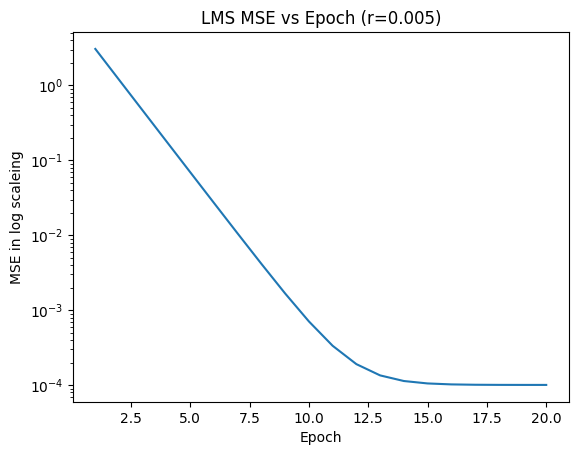

In [ ]:
####----- PART B: -----####

W_0 = [-0.2, 0.0, 0.45]
W_lms, mse_hist = lms_algo(X, D, W_0, 0.005, 20)
print("W_lms =", W_lms)

plt.plot(range(1, 21), mse_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE in log scaleing")
plt.title("LMS MSE vs Epoch (r=0.005)")
plt.show()

**Part B:**

*   The final weight after 20 epochs is [ 1.00066744  1.0005943  -2.00030134]


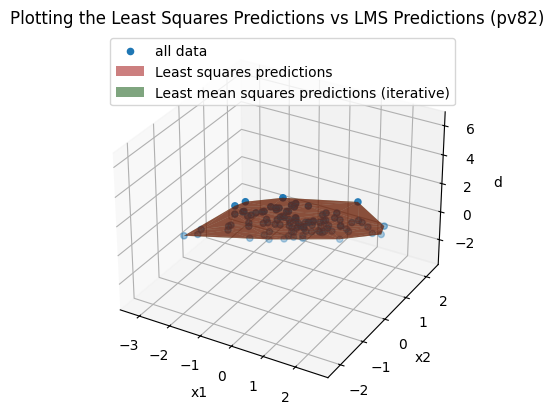

In [ ]:
####----- PART C: -----####

plot_stuff(X, D, W_star, W_lms)



**Part C**

*   The linear modles do fit the data well because the points are well covered by the two surfaces. Although I plotted one to be red and one to be green, they have a lot of overlap over one another, and are pretty much on top of one another, so in the diagram it looks like there is only one surface which is brown.



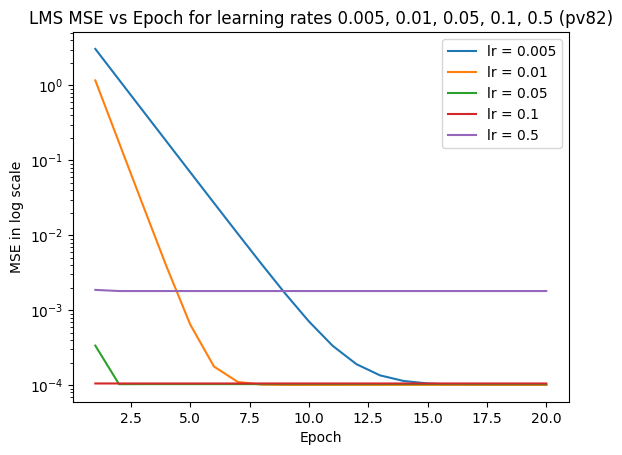

/tmp/ipykernel_1406/1120873233.py:19: RuntimeWarning: overflow encountered in square
  squared_errors = error ** 2


W (lr=1) = [ 1.28471518e+188 -4.10303918e+187 -1.33708699e+188]


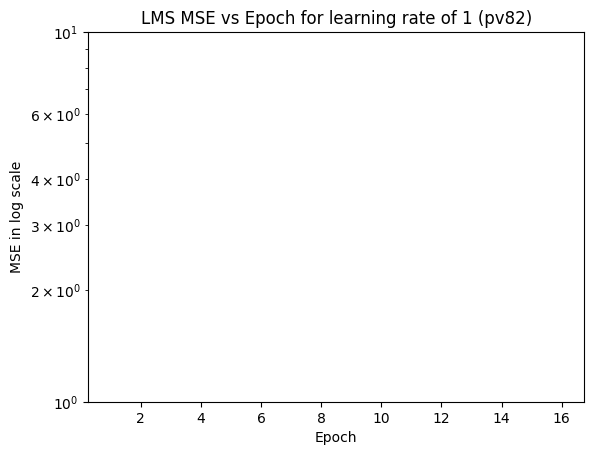

In [ ]:
####----- PART D: -----####

learning_rates = [0.005, 0.01, 0.05, 0.1, 0.5]
mses = {}

for lr in learning_rates:
    W_r, hist = lms_algo(X, D, W_0, lr, 20)
    mses[lr] = hist

plt.figure()
for lr, hist in mses.items():
    plt.plot(range(1, 21), hist, label=f"lr = {lr}")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE in log scale")
plt.title("LMS MSE vs Epoch for learning rates 0.005, 0.01, 0.05, 0.1, 0.5 (pv82)")
plt.legend()
plt.show()

# lr = 1

W_lr1, mses_for_1 = lms_algo(X, D, W_0, 1, 20)
print("W (lr=1) =", W_lr1)

plt.figure()
plt.plot(range(1, 21), mses_for_1)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE in log scale")
plt.title("LMS MSE vs Epoch for learning rate of 1 (pv82)")
plt.show()

**Part D:**
*   A larger learning rate in general means that the error decreases faster and the weights converge faster. However, when the learning rate increases too much, such as when lr = 0.5, the error stops improving and plateus before it reaches the point where it is actually really low. This training instability is because the learning rate is too large compared to the curvature of the error surface and overshoots past where the minimum actually is. If you were to visualize it, the whole thing is like a bowl and the model is trying to find the bottom of the bowl where the gradient is the least. However, if the learning rate is too big and the bowl is too steep, then the model just jumps to the other side of it without actually finding the minimum value. When r = 1, the learning rate way too large that instead of landing just on the other side of the bowl/error surface, it ends up higher up where the error is larger. Over the epochs, the error actually grows bigger and bigger, causing the issue where it blows up to infinity.
